In [70]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt
from tqdm import tqdm
import os


In [71]:

# Data import:
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Momentum_vs_Value_trend']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_featureset = pd.read_csv("featureset.csv", parse_dates=['Date'],na_values=['NA'])
df_featureset = df_featureset.set_index('Date')

df_features = pd.read_csv("factor_relative_features.csv", parse_dates=['Date'])
df_features = df_features.set_index('Date')

data = pd.concat([df_featureset,df_features,df_factor], axis=1, join='inner')
# --- Drop features with more than 30% missing values ---
threshold = 0.3
missing_ratio = data.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > threshold].index
data = data.drop(columns=cols_to_drop)


feature_names = data.columns[:-1]

# --- Forward-fill remaining missing values ---
data = data.ffill()
data = data.dropna()

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values


#X = pd.DataFrame(X, columns=feature_names)
print(data)


            VolTermStructPC1  VolTermStructPC2  VolTermStructPC1_QS  \
Date                                                                  
2012-03-05         44.989431        -10.940336                 0.39   
2012-03-12         42.132833        -11.745842                 0.22   
2012-03-19         40.388607        -11.294753                 0.11   
2012-03-26         36.869615        -10.228845                 0.01   
2012-04-02         38.620657         -9.588153                 0.07   
...                      ...               ...                  ...   
2024-01-01         31.661633         -9.617528                 0.01   
2024-01-08         31.568234         -8.751940                 0.01   
2024-01-15         31.391127         -8.478356                 0.01   
2024-01-22         31.109722         -8.142548                 0.01   
2024-01-29         31.655673         -8.042846                 0.04   

            VolTermStructPC2_QS  VolSpread6M  VIX.Index  VIX3M.Index  \
Date

In [72]:
data.to_csv("data.csv",index=True)

In [222]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt
from tqdm import tqdm
import os


# ======================================================
# 1. Normalized Mutual Information
# ======================================================
def normalized_mi(x, y, n_bins=20):
    # Use separate discretizers to avoid identical binning
    kb_x = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    kb_y = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')

    x_binned = kb_x.fit_transform(x.reshape(-1, 1))
    y_binned = kb_y.fit_transform(y.reshape(-1, 1))

    mi = mutual_info_score(x_binned[:, 0], y_binned[:, 0])
    h_x = mutual_info_score(x_binned[:, 0], x_binned[:, 0])
    h_y = mutual_info_score(y_binned[:, 0], y_binned[:, 0])

    denom = max(h_x, h_y)
    return 0 if denom == 0 else mi / denom


# ======================================================
# 2. Build the MI Distance Matrix (1 - NMI)
# ======================================================
def mi_distance_matrix(X, n_bins=20):
    n = X.shape[1]
    dist_matrix = np.zeros((n, n))
    cols = X.columns.to_list()

    print(f"Computing MI distance matrix for {n} features...")

    for i in tqdm(range(n)):
        for j in range(i + 1, n):
            try:
                nmi = normalized_mi(X.iloc[:, i].values, X.iloc[:, j].values, n_bins=n_bins)
                dist = 1 - nmi
            except Exception:
                dist = 1  # default max distance on failure
            dist_matrix[i, j] = dist_matrix[j, i] = dist

    np.fill_diagonal(dist_matrix, 0)
    return pd.DataFrame(dist_matrix, index=cols, columns=cols)


# ======================================================
# 3. Cluster Features
# ======================================================
def cluster_features(D, method='ward', threshold=None, n_clusters=None):
    Z = linkage(D, method=method)

    if n_clusters is not None:
        cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
        print(f"Formed {n_clusters} clusters using 'maxclust'.")
    elif threshold is not None:
        cluster_labels = fcluster(Z, t=threshold, criterion='distance')
        print(f"Formed {len(np.unique(cluster_labels))} clusters using distance threshold={threshold}.")
    else:
        raise ValueError("Provide either n_clusters or a distance threshold.")

    return pd.Series(cluster_labels, index=D.index), Z


# ======================================================
# 4. Representative Selection
# ======================================================
"""
def get_cluster_representatives(D, cluster_labels):
    representatives = []

    for c in sorted(cluster_labels.unique()):
        feats = cluster_labels[cluster_labels == c].index
        sub_D = D.loc[feats, feats]

        # Compute average distance to others
        mean_dist = sub_D.mean(axis=1)

        # Representative = minimum average distance
        rep_feature = mean_dist.idxmin()

        representatives.append({
            "Cluster": c,
            "Representative": rep_feature,
            "Mean_Distance": mean_dist[rep_feature]
        })

    return pd.DataFrame(representatives).sort_values("Cluster")
"""
def get_cluster_representatives(D, cluster_labels):
    """
    Given:
      D (pd.DataFrame): MI distance matrix (1 - NMI)
      cluster_labels (pd.Series): cluster id per feature

    Returns:
      DataFrame containing representative per cluster plus diagnostics:
        - Mean_Distance
        - Min_Distance
        - Max_Distance
        - Cluster_Size
    """

    representatives = []

    for c in sorted(cluster_labels.unique()):
        feats = cluster_labels[cluster_labels == c].index
        sub_D = D.loc[feats, feats]

        # Compute distances
        mean_dist = sub_D.mean(axis=1)
        min_dist = sub_D.min(axis=1)
        max_dist = sub_D.max(axis=1)

        # Representative = feature with lowest mean distance
        rep_feature = mean_dist.idxmin()

        representatives.append({
            "Cluster": c,
            "Representative": rep_feature,
            "Mean_Distance": mean_dist[rep_feature],
            "Max_Distance": max_dist[rep_feature],
            "Cluster_Size": len(feats)
        })

    return pd.DataFrame(representatives).sort_values("Cluster")




In [ ]:
# ======================================================
# 5. Application
# ======================================================

# Ensure X is a DataFrame
X = pd.DataFrame(X, columns=feature_names)

# Step 1: distance matrix
D = mi_distance_matrix(X)

In [226]:

# Step 2: cluster features
cluster_labels, Z = cluster_features(D, n_clusters=38)
# Alternative:
#cluster_labels, Z = cluster_features(D, threshold=1.2)

# Step 3: get representatives
representatives = get_cluster_representatives(D, cluster_labels)


Formed 38 clusters using 'maxclust'.


C:\Users\p528552\AppData\Local\Temp\ipykernel_15132\2408817837.py:57: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method=method)


In [227]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform

def choose_optimal_clusters(D, min_k=5, max_k=50):
    D_condensed = squareform(D.values)  # required for hierarchical clustering
    scores = {}

    for k in range(min_k, max_k + 1):
        labels = fcluster(Z, t=k, criterion='maxclust')
        score = silhouette_score(D, labels, metric='precomputed')
        scores[k] = score
    
    return scores

scores = choose_optimal_clusters(D)

best_k = max(scores, key=scores.get)
print("Optimal number of clusters =", best_k)


Optimal number of clusters = 38


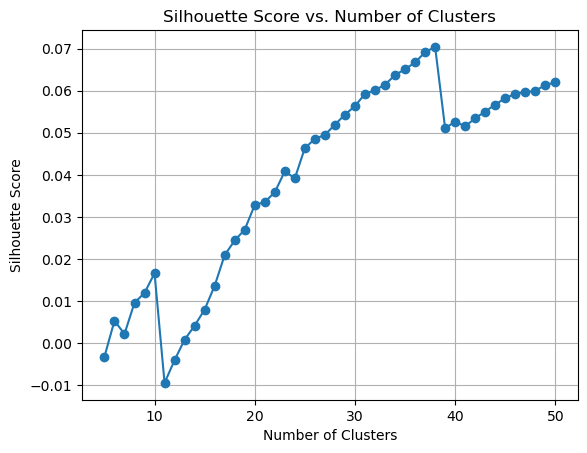

In [228]:
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


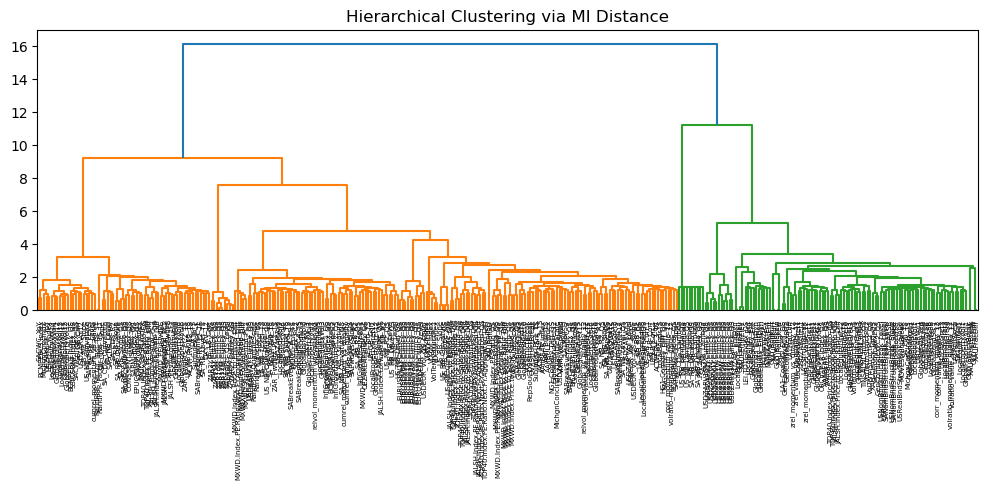

In [229]:
# View cluster representatives
#print("\nRepresentative features per cluster:")
#print(representatives[["Cluster", "Representative", "Mean_Distance"]])

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=D.index, leaf_rotation=90)
plt.title("Hierarchical Clustering via MI Distance")
plt.tight_layout()
plt.show()




In [230]:
display(representatives.style.background_gradient(cmap="viridis", subset=["Mean_Distance","Max_Distance"])
                             .bar(subset=["Cluster_Size"], color="darkblue"))


,Cluster,Representative,Mean_Distance,Max_Distance,Cluster_Size
0,1,BCMPEBLS.Index,0.518573,0.617057,22
1,2,RandPPP_Factor_Inst_TS_ST,0.000000,0.000000,2
2,3,SA_CDS_Slope,0.437258,0.674201,5
3,4,SA_RB_Curvature,0.380144,0.584034,4
4,5,CONCCONF.Index,0.525298,0.641032,7
5,6,JALSH_Fundamental_PC1,0.661095,0.738818,25
6,7,ZAR18M.Curncy_QS,0.238151,0.435217,9
7,8,MXWD_Fundamental_PC1,0.419429,0.577590,5
8,9,USDZARV3Y.Curncy_QS,0.528863,0.800203,4
9,10,LocalBondsVol6,0.723252,0.789051,25


In [ ]:
# View cluster representatives
representatives.head(30)


,Cluster,Representative,Mean_Distance,Max_Distance,Cluster_Size
0,1,BCMPEBLS.Index,0.518573,0.617057,22
1,2,RandPPP_Factor_Inst_TS_ST,0.000000,0.000000,2
2,3,SA_CDS_Slope,0.437258,0.674201,5
3,4,SA_RB_Curvature,0.380144,0.584034,4
4,5,CONCCONF.Index,0.525298,0.641032,7
5,6,JALSH_Fundamental_PC1,0.661095,0.738818,25
6,7,ZAR18M.Curncy_QS,0.238151,0.435217,9
7,8,MXWD_Fundamental_PC1,0.419429,0.577590,5
8,9,USDZARV3Y.Curncy_QS,0.528863,0.800203,4
9,10,LocalBondsVol6,0.723252,0.789051,25
